#Arquivo criado para hospedar os códigos e respostas das perguntas 1 a 10 do arquivo "perguntas_sql.md" em Python.

**#Primeiro passo**: importação das bases de dados do GCP.

In [9]:
import basedosdados as bd
import pandas as pd

PROJECT_ID = "desafio-empm-ulisses-gomes" 

print("Baixando dados do GCP")

# Baixando as tabelas 'dados_mestres_bairro' e 'turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos'.
df_bairros = bd.read_sql("SELECT * FROM `datario.dados_mestres.bairro`", billing_project_id=PROJECT_ID)
df_eventos = bd.read_sql("SELECT * FROM `datario.turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos`", billing_project_id=PROJECT_ID)

#Baixando a tabela 'adm_central_atendimento_1746.chamado' com o filtros para não exceder a cota de consultas.
#Para as perguntas de 1 a 5, baixamos apenas os chamados do dia 01/04/2023
query_p1 = "SELECT * FROM `datario.adm_central_atendimento_1746.chamado` WHERE DATE(data_inicio) = '2023-04-01'"
df_chamados_p1 = bd.read_sql(query_p1, billing_project_id=PROJECT_ID)
#Para as perguntas 6 a 10, baixamos apenas os chamados de Perturbação do Sossego entre 2022 e 2024.
query_p2 = """
SELECT * FROM `datario.adm_central_atendimento_1746.chamado` 
WHERE id_subtipo = '5071' AND DATE(data_inicio) BETWEEN '2022-01-01' AND '2024-12-31'
"""
df_chamados_p2 = bd.read_sql(query_p2, billing_project_id=PROJECT_ID)

#Transformando as colunas de datas para o formato 'datetime.date' do pandas.
df_chamados_p2['data_inicio'] = pd.to_datetime(df_chamados_p2['data_inicio']).dt.date
df_eventos['data_inicial'] = pd.to_datetime(df_eventos['data_inicial']).dt.date
df_eventos['data_final'] = pd.to_datetime(df_eventos['data_final']).dt.date

print("Bases carregadas")

2026-03-03 19:59:58.831 | WARNING  | basedosdados._warnings:show_warnings:94 - You are using an outdated version of basedosdados (2.0.2). Please upgrade to the latest version (2.0.3) using 'pip install --upgrade basedosdados'.


Baixando dados do GCP
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Bases carregadas


**#PERGUNTA 1**- Quantos chamados foram registrados no dia 01/04/2023?

In [10]:
#Objetivo do código, aplicar 'len' para contar o número de chamados registrados no dia 01/04/2023.
q1_resposta = len(df_chamados_p1)
print(f"Resposta: foram registrados {q1_resposta} chamados em 01/04/2023:")

Resposta: foram registrados 2067 chamados em 01/04/2023:


**#PERGUNTA 2**- Qual foi o bairro com o maior número de chamados registrados no dia 01/04/2023?

In [11]:
# Objetivo da código: aplicar 'valuecounts e 'idxmax' para contar os chamados e retornar apenas o chamado mais registrado
q2_resposta = df_chamados_p1['tipo'].value_counts().idxmax()
print(f"Resposta: o chamado mais registrado foi o de '{q2_resposta}'")

Resposta: o chamado mais registrado foi o de 'Estacionamento irregular'


#Mesclagem 'merge' das tabelas 'dados_mestres_bairro' e 'adm_central_atendimento_1746.chamado'

In [12]:
df_merged_p1 = df_chamados_p1.merge(df_bairros, on='id_bairro', how='left')
print("Mesclagem executada")

Mesclagem executada


**#PERGUNTA 3**- Quais os nomes dos 3 bairros que mais tiveram chamados abertos nesse dia?

In [14]:
#objetivo do código: aplicar 'valuecounts' para contar os chamados por bairro e 'head(3)' para retornar apenas os 3 maiores.
q3_resposta = df_merged_p1['nome'].value_counts().head(3) #Retorna apenas os 3 bairros geo-referenciados nas reclamações com mais chamados registrados.
print("\n" + "_" * 55)
print("RESULTADO: TOP 3 BAIRROS")
print("_" * 55)
for posicao, (bairro, quantidade) in enumerate(q3_resposta.items(), start=1): #Itera por meio do 'enumerate' sobre os bairros e suas respectivas quantidades, formatando a saída para exibir a posição, nome do bairro e quantidade de chamados.
    print(f" {posicao}º Lugar | {bairro.ljust(25)} | {quantidade} chamados")

print("_" * 55 + "\n")


_______________________________________________________
RESULTADO: TOP 3 BAIRROS
_______________________________________________________
 1º Lugar | Campo Grande              | 125 chamados
 2º Lugar | Tijuca                    | 100 chamados
 3º Lugar | Barra da Tijuca           | 62 chamados
_______________________________________________________



**Observação** Como descobrimos na nossa exploração inicial em SQL (Pergunta 3 e 5), existem chamados no sistema 1746 que não possuem um 'id_bairro' associado. Geralmente, são serviços atrelados a entidades móveis (como reclamações de linhas de Ônibus ou BRT) ou serviços digitais, que não possuem geolocalização fixa. 

Como a função 'value_counts()' tem como parâmetro o 'dropna=True', que desconsidera os valores nulos, optou-se aqui pelo uso dessa função e assim não evidenciar as reclamações não geolocalizadas, como foi evidenciado na consulta SQL.

**PERGUNTA 4**- Qual o nome da subprefeitura com mais chamados abertos nesse dia?

In [21]:
#Objetivo do código: aplicar 'valuecounts' para contar os chamados por subprefeitura e 'idxmax' para retornar apenas a subprefeitura com mais chamados registrados.
q4_resposta = df_merged_p1['subprefeitura'].value_counts().idxmax()
print(f"\nResposta: A subprefeitura com mais chamados foi a '{q4_resposta}'")


Resposta: A subprefeitura com mais chamados foi a 'Subprefeitura da Zona Norte'


**PERGUNTA 5:** - Existe algum chamado aberto nesse dia que não foi associado a um bairro ou subprefeitura na tabela de bairros? Se sim, por que isso acontece?

In [27]:
#Objetivo do código: aplicar 'isnull' para identificar os chamados sem bairro associado e 'len' para contar quantos são.
chamados_sem_bairro = df_merged_p1[df_merged_p1['id_bairro'].isnull()]
print(f"\nResultado: Sim, existem {len(chamados_sem_bairro)} chamados sem bairro associado.")
print("Motivação:Ao analisar a consulta, observa-se que esses chamados se referem a trasnportes como 'Veículos' e /ou 'BRT (corredor expresso de ônibus)' - de maneira similar a pergunta 3 - 'Fiscalização Eletrônica' e 'Ouvidoria - CLF'")


Resultado: Sim, existem 260 chamados sem bairro associado.
Motivação:Ao analisar a consulta, observa-se que esses chamados se referem a trasnportes como 'Veículos' e /ou 'BRT (corredor expresso de ônibus)' - de maneira similar a pergunta 3 - 'Fiscalização Eletrônica' e 'Ouvidoria - CLF'


**PERGUNTA 6**- Quantos chamados de Perturbação do sossego foram abertos nesse período (01/01/2022 a 31/12/2024)?

In [34]:
#Objetivo do código: aplicar 'len' para contar o número de chamados de perturbação do sossego registrados entre 2022 e 2024.
q6_resposta = len(df_chamados_p2)
print(f"Resultado:Total de chamados de perturbação do sossego (2022-2024): {q6_resposta} chamados")

Resultado:Total de chamados de perturbação do sossego (2022-2024): 57532 chamados


**Etapa intermediária:** Corrigindo padrão de datas da tabela 'datario.turismo_fluxo_visitantes.rede_hoteleira_ocupacao_eventos'

In [22]:
#Objetivo do código: fazer o tratamento dos dados para corrigir os eventos com datas despadronizadas(Rock in Rio e Réveillon) e unir com os eventos que já possuem as datas corretas preenchidas, para posteriormente cruzar com os chamados e analisar o impacto dos eventos nos chamados de perturbação do sossego.
import pandas as pd

df_eventos_limpo = df_eventos.dropna(subset=['data_inicial', 'data_final']).copy() #Filtra apenas os eventos que já possuem as datas corretas

#Corrige apenas as datas dos eventos que estão com informações despadronizadas(Rock in Rio e Réveillon)
eventos_corrigidos = pd.DataFrame({
    'evento': ['Rock in Rio', 'Rock in Rio', 'Reveillon'],
    'data_inicial': ['2024-09-13', '2024-09-19', '2024-12-29'],
    'data_final': ['2024-09-15', '2024-09-22', '2025-01-01']
})
eventos_corrigidos['data_inicial'] = pd.to_datetime(eventos_corrigidos['data_inicial']).dt.date #converte as colunas de datas para o formato 'datetime.date'

df_eventos_tratado = pd.concat([df_eventos_limpo, eventos_corrigidos], ignore_index=True)
print(df_eventos_tratado.to_string())

                            ano data_inicial  data_final       evento  taxa_ocupacao
0         18/02 a 21/02 de 2023   2023-02-18  2023-02-21     Carnaval         0.9554
1            10/02 a 14/02/2024   2024-02-10  2024-02-14     Carnaval            NaN
2         02/09 a 04/09 de 2022   2022-09-02  2022-09-04  Rock in Rio         0.8184
3         08/09 a 11/09 de 2022   2022-09-08  2022-09-11  Rock in Rio         0.9451
4  30-31/12 e 01/01 (2022-2023)   2022-12-30  2023-01-01    Réveillon         0.9251
5  30-31/12 e 01/01 (2023-2024)   2023-12-30  2024-01-01    Réveillon            NaN
6                           NaN   2024-09-13  2024-09-15  Rock in Rio            NaN
7                           NaN   2024-09-19  2024-09-22  Rock in Rio            NaN
8                           NaN   2024-12-29  2025-01-01    Reveillon            NaN


**PERGUNTA 7**-Selecione os chamados com esse subtipo que foram abertos durante os eventos contidos na tabela de eventos (Reveillon, Carnaval e Rock in Rio).

In [25]:
df_cross = df_chamados_p2.merge(df_eventos_tratado, how='cross')

# PADRONIZANDO TODAS AS COLUNAS PARA O MESMO FORMATO DE DATA (IGNORANDO AS HORAS) PARA EVITAR O TYPEERROR
df_cross['data_inicio'] = pd.to_datetime(df_cross['data_inicio']).dt.normalize()
df_cross['data_inicial'] = pd.to_datetime(df_cross['data_inicial']).dt.normalize()
df_cross['data_final'] = pd.to_datetime(df_cross['data_final']).dt.normalize()

df_chamados_eventos = df_cross[(df_cross['data_inicio'] >= df_cross['data_inicial']) & 
                               (df_cross['data_inicio'] <= df_cross['data_final'])]

print("\nResultado:Total de chamados de perturbação do sossego durante os eventos foi de", len(df_chamados_eventos))


Resultado:Total de chamados de perturbação do sossego durante os eventos foi de 1511


**PERGUNTA 8**-Quantos chamados desse subtipo foram abertos em cada evento?

In [30]:
#Etapa intermediária: importando a biblioteca 'matplotlib' para visualização de dados.
import matplotlib.pyplot as plt

In [43]:
#Objetivo do código: calcular o total de chamados de perturbação do sossego durante cada evento.
df_chamados_eventos['evento'] = df_chamados_eventos['evento'].str.replace('é', 'e').str.replace('É', 'E') #normalziando nomes

#Calcula o total de chamados de perturbação do sossego durante cada evento.
q8_resposta = df_chamados_eventos['evento'].value_counts()
q8_resposta.name = 'count'
print("\nResposta:Chamados por Evento:")
display(q8_resposta)


Resposta:Chamados por Evento:


evento
Rock in Rio    958
Reveillon      298
Carnaval       255
Name: count, dtype: int64

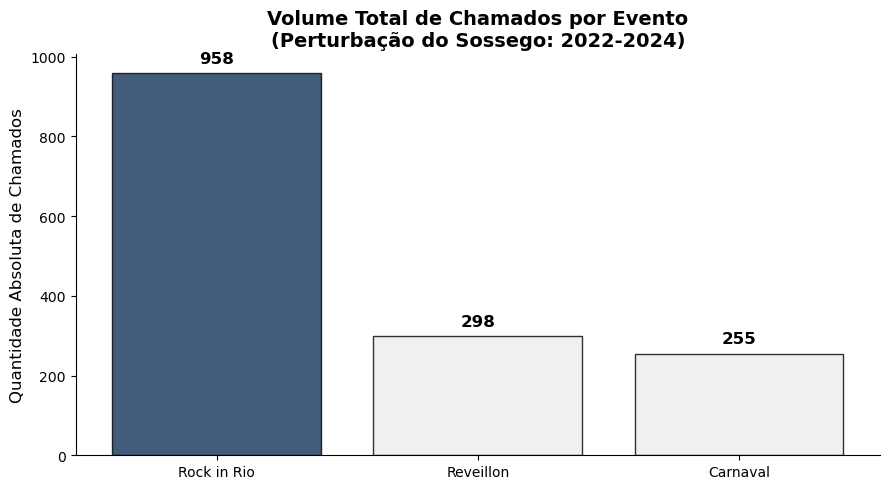

In [44]:
#Objetivo do código: extrair os eventos e as quantidades de chamados para listas separadas, e monstar um gráfico com 'matplotlib.pyplot'.
eventos = q8_resposta.index.tolist() #extrai os eventos e as quantidades de chamados para listas separadas, facilitando a construção do gráfico.
total_chamados = q8_resposta.values.tolist()
plt.figure(figsize=(9, 5))#configura o tamanho da figura
#adicionando cores personalizadas presentes no manual de marca da prefeitura do Rio de Janeiro.
cores_eventos = ['#13335a'] + ['#eceded'] * (len(eventos) - 1)
barras = plt.bar(eventos, total_chamados, color=cores_eventos, edgecolor='black', alpha=0.8)
plt.title('Volume Total de Chamados por Evento\n(Perturbação do Sossego: 2022-2024)', fontsize=14, fontweight='bold')#Adiciona títulos e rótulos aos eixos
plt.ylabel('Quantidade Absoluta de Chamados', fontsize=12)
#calcula uma posição para os rótulos de dados para evitar sobreposição de barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + (max(total_chamados) * 0.02),
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.gca().spines['top'].set_visible(False)#Remoção a borda superior da figura
plt.gca().spines['right'].set_visible(False)
#Exibição do resultado
plt.tight_layout()
plt.show()

**Observação:** Como pode ser observado no gráfico acima, O Rock in Rio é o evento que mais distoa dos demais com reclamações de perrturbação do sossego necessitando então de um maior incremento a fiscalização desse tipo de chamado nas datas desse evento

**PERGUNTA 9**-Qual evento teve a maior média diária de chamados abertos desse subtipo?

In [57]:
#objetivo do código: calcular a média diária de chamados para cada evento, considerando a duração de cada evento.
import pandas as pd

# --- Normalização igual ao SQL (Q10 faz, mas aqui não atrapalha) ---
df_eventos_tratado = df_eventos_tratado.copy()
df_chamados_p2 = df_chamados_p2.copy()

df_eventos_tratado["evento"] = (
    df_eventos_tratado["evento"].astype(str)
    .str.replace("é", "e", regex=False)
    .str.replace("É", "E", regex=False)
    .str.strip()
)

# Datas como DATE (equivalente ao DATE(c.data_inicio))
df_eventos_tratado["data_inicial"] = pd.to_datetime(df_eventos_tratado["data_inicial"], errors="coerce").dt.date
df_eventos_tratado["data_final"]   = pd.to_datetime(df_eventos_tratado["data_final"], errors="coerce").dt.date

# --- EventosTratados do SQL: remove nulos + UNION ALL extras ---
eventos_trat = df_eventos_tratado.dropna(subset=["data_inicial", "data_final"])[
    ["evento", "data_inicial", "data_final"]
].copy()

extras = pd.DataFrame({
    "evento": ["Rock in Rio", "Rock in Rio", "Reveillon"],
    "data_inicial": [
        pd.to_datetime("2024-09-13").date(),
        pd.to_datetime("2024-09-19").date(),
        pd.to_datetime("2024-12-29").date(),
    ],
    "data_final": [
        pd.to_datetime("2024-09-15").date(),
        pd.to_datetime("2024-09-22").date(),
        pd.to_datetime("2025-01-01").date(),
    ],
})

eventos_trat = pd.concat([eventos_trat, extras], ignore_index=True)

# --- Filtrar chamados igual ao SQL ---
df_chamados_p2["data_inicio"] = pd.to_datetime(df_chamados_p2["data_inicio"], errors="coerce").dt.date
ch = df_chamados_p2.dropna(subset=["data_inicio"]).copy()

ch = ch[
    (ch["id_subtipo"] == "5071") &
    (ch["data_inicio"] >= pd.to_datetime("2022-01-01").date()) &
    (ch["data_inicio"] <= pd.to_datetime("2024-12-31").date())
].copy()

# --- JOIN BETWEEN (igual ao SQL) via chave dummy (evita how='cross') ---
ch["_k"] = 1
eventos_trat["_k"] = 1

cross = ch.merge(eventos_trat, on="_k", how="inner").drop(columns="_k")

ch_eventos = cross[
    (cross["data_inicio"] >= cross["data_inicial"]) &
    (cross["data_inicio"] <= cross["data_final"])
].copy()

# --- Agregação igual ao SQL Q9 (COUNT + MAX/MAX + media) ---
res_q9 = ch_eventos.groupby("evento", as_index=False).agg(
    total_chamados=("id_chamado", "count"),
    max_data_inicial=("data_inicial", "max"),
    max_data_final=("data_final", "max"),
)

res_q9["dias_de_evento"] = (
    (pd.to_datetime(res_q9["max_data_final"]) - pd.to_datetime(res_q9["max_data_inicial"])).dt.days + 1
)

res_q9["media_diaria"] = res_q9["total_chamados"] / res_q9["dias_de_evento"]

# LIMIT 1
campeao_media = res_q9.sort_values("media_diaria", ascending=False).iloc[0]

print(
    f"\nResultado: O evento com maior média diária foi o {campeao_media['evento']} "
    f"com {campeao_media['media_diaria']:.2f} chamados/dia."
)


Resultado: O evento com maior média diária foi o Rock in Rio com 239.50 chamados/dia.


**PERGUNTA 10**-Compare as médias diárias de chamados abertos desse subtipo durante os eventos específicos (Reveillon, Carnaval e Rock in Rio) e a média diária de chamados abertos desse subtipo considerando todo o período de 01/01/2022 até 31/12/2024.

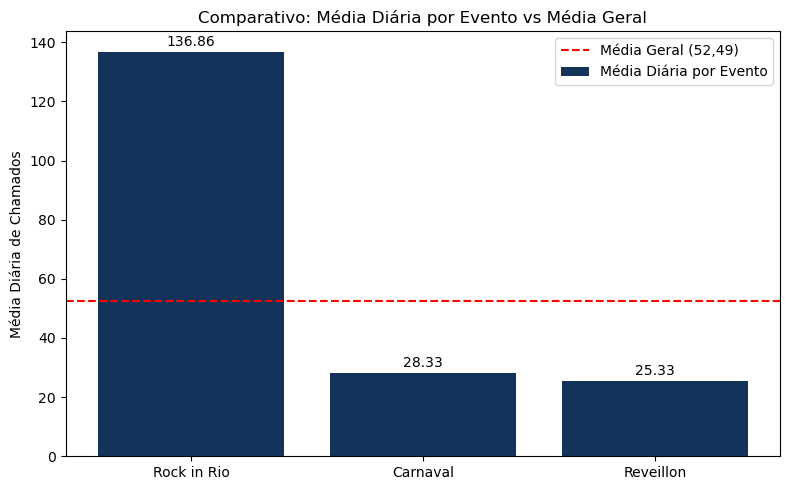

In [73]:
#objetivo do código: comparar a média diária de chamados para cada evento com a média geral de chamados por dia no período de 2022 a 2024, por meio de um gráfico comparativo.
import matplotlib.pyplot as plt #aqui foi escolhido a montagem dos valores diretos em um gráfico para facilitar a visualização comparativa entre os eventos e a média geral de chamados por dia já executada via SQL
data = {
    'evento': ['Rock in Rio', 'Carnaval', 'Reveillon'],
    'media_diaria_evento': [136.86, 28.33, 25.33],
    'media_diaria_geral': [52.49, 52.49, 52.49]
}
df = pd.DataFrame(data) #montando os valores em um DataFrame para facilitar a construção do gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df['evento'], df['media_diaria_evento'], color='#13335a', label='Média Diária por Evento')
ax.axhline(y=52.49, color='red', linestyle='--', label='Média Geral (52,49)')

for bar in bars: #adicionando rótulo de dados
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}', ha='center', va='bottom')

ax.set_ylabel('Média Diária de Chamados') #ajustando visualização
ax.set_title('Comparativo: Média Diária por Evento vs Média Geral')
ax.legend()
plt.tight_layout()

plt.show()

**Observação:** A análise do resultado da Pergunta 10, visualizadas no gráfico acima, indica que a média diária geral de reclamações de perturbação ao sossego foi de 52,49 chamados por dia ao longo desses 3 anos. 
Considerando a média diária conjunta de todas as ocorrências dos eventos solicitados, verificamos que apenas um evento superou a média diária do período analisado. O Rock in Rio registrou uma média de 136,86 chamados por dia (mais de 2,5 vezes a média diária geral para esse subtipo de chamado no período observado). 
O Carnaval (com média de 28,33) e o Reveillon (25.33) registraram valor acima da média diária calculada ao longo dos 3 anos. Com isso, observamos o potencial que o Rock in Rio têm de impactar negativamente a vida dos cidadãos cariocas. 
Portanto, recomenda-se a ampla divulgação do serviço de fiscalização de perturbação do sossego, por meio da Central de Atendimento 1746, antes e durante o Rock in Rio.
Essa divulgação deve ser intensificada em mídias tradicionais, como rádio e TV aberta, e também em canais digitais e redes sociais, incluindo a página oficial da Prefeitura e a republicação por perfis institucionais de grande alcance, como o COR-Rio no Instagram, que possui elevado engajamento e frequente acompanhamento junto à população carioca. 
De forma complementar, recomenda-se a suplementação e maior integração estratégica entre as equipes de fiscalização e as responsáveis pelo tratamento e encaminhamento dos chamados durante esses eventos, com o objetivo de ampliar a eficiência operacional, reduzir o tempo de resposta e qualificar o atendimento à população. 
De forma parelela, essa análise pode ser incrementada a partir do cruzamento das informações de geolocalização dos chamados de perturbação do sossego durante as edições do Rock in Rio para verificar se esses chamados, durante os dias do evento, se concentram em regiões ou bairros próximos a "Cidade do Rock" na Barra da Tijuca.
Com a adição desse prisma analítico, poderíamos aumentar o nexo causal entre as edições do Rock in Rio e o aumento substancial de reclamações relacionadas a perturbação do sossego, incrementando assim a capacidade de planejamento e tomada de decisão da prefeitura para as edições futuras do Rock in Rio.